# Extension 2 — Functional misspecification: quadratic-shock VAR(4) DGP (Ch. 5)

Stress-tests the Ch. 3 baseline ranking under **functional misspecification**. The linear VAR(4) is augmented by a mean-zero quadratic term in the first structural shock,
$$ y_t=\sum_{i=1}^4 A_i y_{t-i}+u_t+\gamma\cdot c(\varepsilon_{1,t}),\qquad c(\varepsilon_{1,t})=(0,\ \varepsilon_{1,t}^2-1)',\quad u_t=B\varepsilon_t,\quad \varepsilon_t\sim\mathcal N(0,I_2), $$
with nonlinearity strength $\gamma\in\{0,0.3,0.6\}$ ($\gamma=0$ nests the baseline VAR(4)). The quadratic enters the **second equation only**; the lag matrices $A_i$ and impact matrix $B$ are inherited from the baseline, so **all** variation is the nonlinear term.

The centring $\varepsilon_{1,t}^2-1$ makes $c$ **mean-zero**, so the best *linear* approximation to the IRF — the estimand $\theta_h^{\mathrm{lin}}=(\Psi_h B)[1,1]$ — is **$\gamma$-invariant** and equals the baseline VAR(4) IRF. Both LP and VAR target this same linear object in population \[Plagborg-Møller & Wright, Prop. 1\], so unlike the invertible VARMA of Extension 1 the quadratic is **not** approximable by higher-order linear VARs: the complexity-adjusted VAR($q$) sweep has **no approximation advantage** here. Any finite-sample divergence is therefore the **inference channel** — the nonlinear DGP generates non-Gaussian, square-dependent Wold innovations — not differential bias. Estimators (fixed **LP(4)** and the **VAR($q$) sweep**) are applied **unchanged**.

In [43]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import (QuadShockVARSpec, simulate_quad_shock_var, quad_shock_irf,
                       scale_to_persistence, spectral_radius)
from mcsim.estimators import estimate_lp_irf, estimate_var_irf
from mcsim.simulation import MCConfig, run

## 0. Set up model parameters

In [44]:
# Define the persistence scenario to run. Can be "LOW" (rho = 0.5), "MID" (rho = 0.7), "HIGH" (rho = 0.95)
Scenario = "LOW"

In [45]:
P = 4
H = 20
RHO_SCENARIO = {"LOW": 0.5, "MID": 0.7, "HIGH": 0.95}
RHO = RHO_SCENARIO[Scenario]                         # Rho in {0.5, 0.7, 0.95}

T = [100, 200, 240, 500]
GAMMAS = [0.0, 0.3, 0.6]          # nonlinearity strength (gamma=0 nests the baseline VAR(4))
T_SHOW = 240                      # sample size used for the per-gamma diagnostic panels

M  = np.array([[0.50, 0.10], [0.10, 0.50]])      # symmetric, positive -> real, decaying
A0 = np.array([M, 0.4 * M, 0.2 * M, 0.1 * M])     # VAR(4): geometrically decaying lag matrices
B  = np.array([[1.0, 0.0], [0.5, 1.0]])           # recursive (lower-triangular) impact matrix
A_RHO = scale_to_persistence(A0, RHO)             # AR part scaled to target persistence; shared across gamma

# Quadratic-shock VAR(4): c(eps1) = (0, eps1^2 - 1)' enters eq. 2; gamma=0 reproduces the baseline VAR(4).
DGPS = {g: QuadShockVARSpec(A=A_RHO, B=B, gamma=g) for g in GAMMAS}

# The estimand is the BEST LINEAR APPROXIMATION = the linear-component IRF. Because the quadratic
# term is mean-zero, this is gamma-INDEPENDENT and equals the baseline VAR(4) IRF: a SINGLE truth
# shared across the whole (gamma, T) design (both LP and VAR target it in population).
TRUTH = quad_shock_irf(DGPS[0.0], H)

hgrid = np.arange(H + 1)
cg = {g: plt.cm.viridis(i / max(len(GAMMAS) - 1, 1)) for i, g in enumerate(GAMMAS)}

print("AR spectral radius (persistence):", round(spectral_radius(A_RHO), 3),
      "| estimand is gamma-invariant (mean-zero quadratic) -> single linear truth")

N_REPS = 5000  # nr of MC reps

AR spectral radius (persistence): 0.5 | estimand is gamma-invariant (mean-zero quadratic) -> single linear truth


## 1. DGP — a $\gamma$-invariant estimand, but non-Gaussian innovations

The mean-zero quadratic term leaves the **best linear approximation** untouched: the true linear estimand $\theta_h=(\Psi_h B)[1,1]$ is **identical for every $\gamma$** (left panel). What the nonlinearity changes is the *shape* of the innovations the linear estimators treat as iid Gaussian. The second-equation innovation $w_{2,t}=(B\varepsilon_t)_2+\gamma(\varepsilon_{1,t}^2-1)$ inherits the right-skew and excess kurtosis of a $\chi^2_1$ as $\gamma$ grows (right panel). This is the **inference channel**: the point estimand is unmoved, but the sampling distribution of $\hat\theta_h$ — and hence CI coverage — is distorted.

/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_9977/2605931379.py:21: RuntimeWarning: divide by zero encountered in matmul
  w2 = (eps @ B.T)[:, 1] + g * (eps[:, 0] ** 2 - 1.0)   # second-equation innovation
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_9977/2605931379.py:21: RuntimeWarning: overflow encountered in matmul
  w2 = (eps @ B.T)[:, 1] + g * (eps[:, 0] ** 2 - 1.0)   # second-equation innovation
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_9977/2605931379.py:21: RuntimeWarning: invalid value encountered in matmul
  w2 = (eps @ B.T)[:, 1] + g * (eps[:, 0] ** 2 - 1.0)   # second-equation innovation


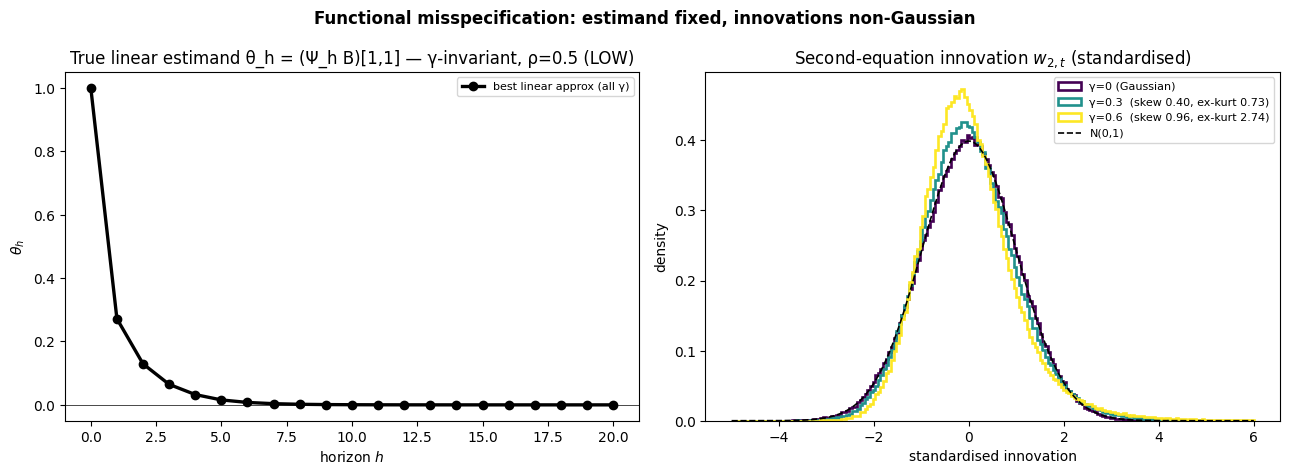

In [46]:
def _moments(x):
    """Sample skewness and excess kurtosis (numpy-only)."""
    z = (x - x.mean()) / x.std()
    return float((z ** 3).mean()), float((z ** 4).mean() - 3.0)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) gamma-invariant best-linear-approximation IRF (one curve for all gamma)
ax = axes[0]
ax.plot(hgrid, TRUTH, "o-", lw=2.4, color="black", label="best linear approx (all γ)")
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"True linear estimand θ_h = (Ψ_h B)[1,1] — γ-invariant, ρ={RHO} ({Scenario})")
ax.set_xlabel("horizon $h$"); ax.set_ylabel(r"$\theta_h$"); ax.legend(fontsize=8)

# (b) non-Gaussianity injected into the second-equation innovation as gamma grows
ax = axes[1]
rng = np.random.default_rng(7)
eps = rng.standard_normal((400_000, 2))
for g in GAMMAS:
    w2 = (eps @ B.T)[:, 1] + g * (eps[:, 0] ** 2 - 1.0)   # second-equation innovation
    sk, ek = _moments(w2)
    w2 = (w2 - w2.mean()) / w2.std()
    lab = "γ=0 (Gaussian)" if g == 0 else f"γ={g}  (skew {sk:.2f}, ex-kurt {ek:.2f})"
    ax.hist(w2, bins=200, range=(-5, 6), density=True, histtype="step", lw=1.9, color=cg[g], label=lab)
xx = np.linspace(-5, 6, 400)
ax.plot(xx, np.exp(-xx ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1.2, label="N(0,1)")
ax.set_title("Second-equation innovation $w_{2,t}$ (standardised)")
ax.set_xlabel("standardised innovation"); ax.set_ylabel("density"); ax.legend(fontsize=8)
fig.suptitle("Functional misspecification: estimand fixed, innovations non-Gaussian", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../figures/Functional_MisSpec/{Scenario}_DGP.png")
plt.show()

## 2. Monte Carlo — LP(4) + VAR(q) sweep × nonlinearity × sample size

The three-way design of Ch. 5: for each $\gamma\in\{0,0.3,0.6\}$ and $T\in\{100,200,240,500\}$ we run the fixed **LP(4)** and the full **VAR(q) sweep** ($q=1\ldots23$) on the quadratic-shock data, **without modification**. The estimand is **both $T$- and $\gamma$-independent** (`TRUTH`), since the quadratic is mean-zero. Raw stacks land in `results[(γ,T)]` and horizon-wise RMSE in `rmse[(γ,T)]`.

In [47]:
VAR_ORDERS = list(range(1, P + H))                  # 1, 2, ..., 23

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in VAR_ORDERS})


def quad_dgp(rng, Tlen, spec):
    return simulate_quad_shock_var(spec, Tlen, rng)


results, rmse = {}, {}                               # keyed by (gamma, T)
for g in GAMMAS:
    for Tval in T:
        cfg = MCConfig(n_reps=N_REPS, T=Tval, horizon=H, seed=42, n_jobs=-1,
                       progress=True, estimators=estimators)
        res = run(partial(quad_dgp, spec=DGPS[g]), cfg)
        results[(g, Tval)] = res
        rmse[(g, Tval)] = {nm: np.sqrt(np.nanmean((st - TRUTH) ** 2, axis=0))
                           for nm, st in res["irfs"].items()}
        fails = {k: v for k, v in res["n_failures"].items() if v}
        print(f"gamma={g:<4} T={Tval:>4}: done  |  failures: {fails or 'none'}")

MC reps: 100%|██████████| 5000/5000 [00:03<00:00, 1502.43it/s]


gamma=0.0  T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:03<00:00, 1345.33it/s]


gamma=0.0  T= 200: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:04<00:00, 1247.11it/s]


...

gamma=0.6  T= 200: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:04<00:00, 1049.63it/s]


gamma=0.6  T= 240: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:06<00:00, 831.90it/s]


gamma=0.6  T= 500: done  |  failures: none


## 3. RMSE comparison: no approximation advantage from extra lags

The **complexity frontier** (horizon-averaged RMSE vs VAR order) at $T=240$, one curve per $\gamma$, with LP(4) as a same-colour dashed reference. Unlike Extension 1, the quadratic term is **not** representable by any finite linear VAR, so increasing $q$ buys **no** bias reduction — the frontier does not fall toward higher orders; past the low-order minimum it only accumulates estimation variance, and the best order is **VAR(3)–VAR(4)**, never a high one. As $\gamma$ grows the curves **shift up only slightly** (the extra innovation variance $\propto\gamma^2$ is modest at these $\gamma$), so the baseline ranking is essentially untouched: VAR(4) keeps its RMSE edge over LP(4) in **every** $(\gamma,T)$ cell. The table reports each cell.

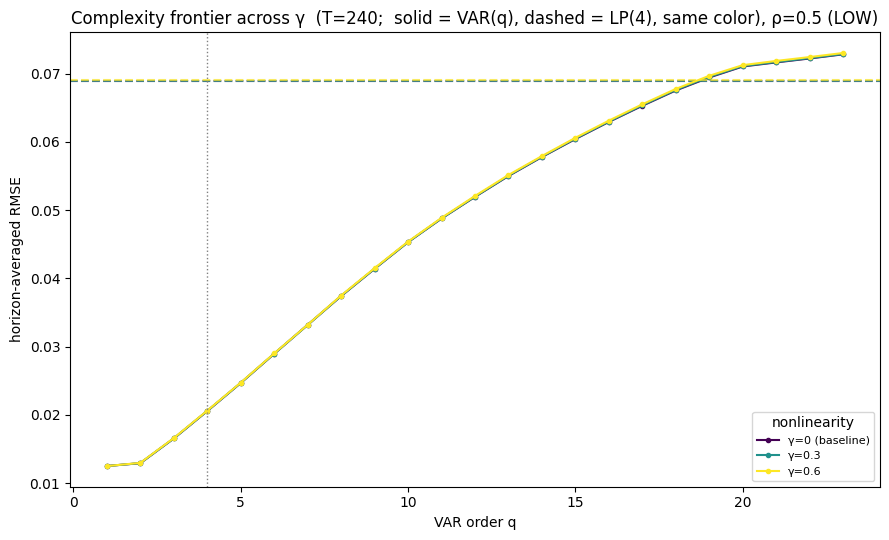

 gamma     T    LP(4)   VAR(4)        bestVAR   LP-VAR4
--------------------------------------------------------
   0.0   100    0.114    0.035   VAR(1)=0.016    +0.079
   0.0   200    0.076    0.023   VAR(1)=0.013    +0.053
   0.0   240    0.069    0.021   VAR(1)=0.013    +0.048
   0.0   500    0.047    0.014   VAR(2)=0.009    +0.033
   0.3   100    0.114    0.035   VAR(1)=0.016    +0.079
   0.3   200    0.076    0.023   VAR(1)=0.013    +0.053
   0.3   240    0.069    0.021   VAR(1)=0.013    +0.048
   0.3   500    0.047    0.014   VAR(2)=0.009    +0.033
   0.6   100    0.114    0.035   VAR(1)=0.017    +0.079
   0.6   200    0.076    0.023   VAR(1)=0.013    +0.053
   0.6   240    0.069    0.021   VAR(1)=0.013    +0.048
   0.6   500    0.047    0.014   VAR(2)=0.009    +0.033
(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)


In [48]:
# (1) complexity frontier per gamma, at T_SHOW
fig, ax = plt.subplots(figsize=(9, 5.5))
for g in GAMMAS:
    rm = rmse[(g, T_SHOW)]
    avg_var = [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS]
    lab = "γ=0 (baseline)" if g == 0 else f"γ={g}"
    ax.plot(VAR_ORDERS, avg_var, "o-", ms=3, color=cg[g], label=lab)
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=cg[g], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)
ax.set_title(f"Complexity frontier across γ  (T={T_SHOW};  solid = VAR(q), dashed = LP(4), same color), ρ={RHO} ({Scenario})")
ax.set_xlabel("VAR order q"); ax.set_ylabel("horizon-averaged RMSE")
ax.legend(fontsize=8, title="nonlinearity")
fig.tight_layout()
plt.savefig(f"../figures/Functional_MisSpec/{Scenario}_COMPLEXITY_FRONTIER.png")
plt.show()

# (2) full (gamma, T) summary table
print(f"{'gamma':>6} {'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>14} {'LP-VAR4':>9}")
print("-" * 56)
for g in GAMMAS:
    for Tval in T:
        rm = rmse[(g, Tval)]
        lp = float(np.mean(rm["LP(4)"])); v4 = float(np.mean(rm["VAR(4)"]))
        avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
        bq = min(avgs, key=avgs.get)
        print(f"{g:>6} {Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>14} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

### RMSE by horizon, per nonlinearity strength

One panel per $\gamma$ at $T=240$: the VAR sweep (dark = low order → yellow = high) with LP(4) and the equal-lag VAR(4) highlighted. Because the misspecification is in the innovation *distribution* and not the conditional mean, all estimators stay tightly bunched — there is no order that escapes the nonlinearity — and the whole bundle lifts as $\gamma$ grows.

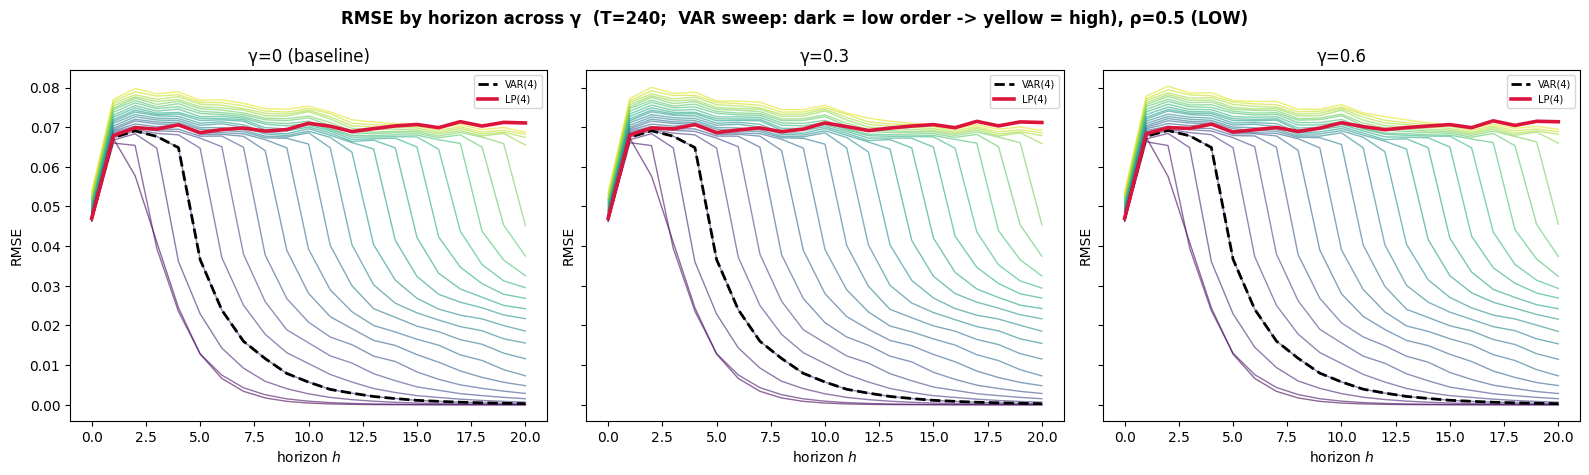

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
for ax, g in zip(axes.ravel(), GAMMAS):
    rm = rmse[(g, T_SHOW)]
    for i, q in enumerate(VAR_ORDERS):
        ax.plot(hgrid, rm[f"VAR({q})"], color=plt.cm.viridis(i / len(VAR_ORDERS)), lw=1, alpha=0.6)
    ax.plot(hgrid, rm["VAR(4)"], "k--", lw=2, label="VAR(4)")
    ax.plot(hgrid, rm["LP(4)"], color="crimson", lw=2.6, label="LP(4)")
    ttl = "γ=0 (baseline)" if g == 0 else f"γ={g}"
    ax.set_title(ttl); ax.set_xlabel("horizon $h$"); ax.set_ylabel("RMSE"); ax.legend(fontsize=7)
fig.suptitle(f"RMSE by horizon across γ  (T={T_SHOW};  VAR sweep: dark = low order -> yellow = high), ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../figures/Functional_MisSpec/{Scenario}_RMSE_BY_HORIZON.png")
plt.show()

## 4. Deviation from truth — finite-sample vs asymptotic

Where does the quadratic bite, and is there any *asymptotic* bias separating the estimators? For each estimator the **deviation of the mean prediction from the truth** ($\hat\theta_h-\theta_h$; truth = the zero line) with the central 90% band (5th–95th pct of the per-replication deviations): the mean line is *bias*, the band width is *dispersion*. At $T=240$ (one panel per $\gamma$ below) VAR(4) and LP(4) sit almost on top of each other, and the picture **barely changes across $\gamma$** — the small short-/long-horizon bias is the ordinary high-persistence finite-sample bias, **not** induced by the nonlinearity — while the wide overlapping bands show variance dominates.

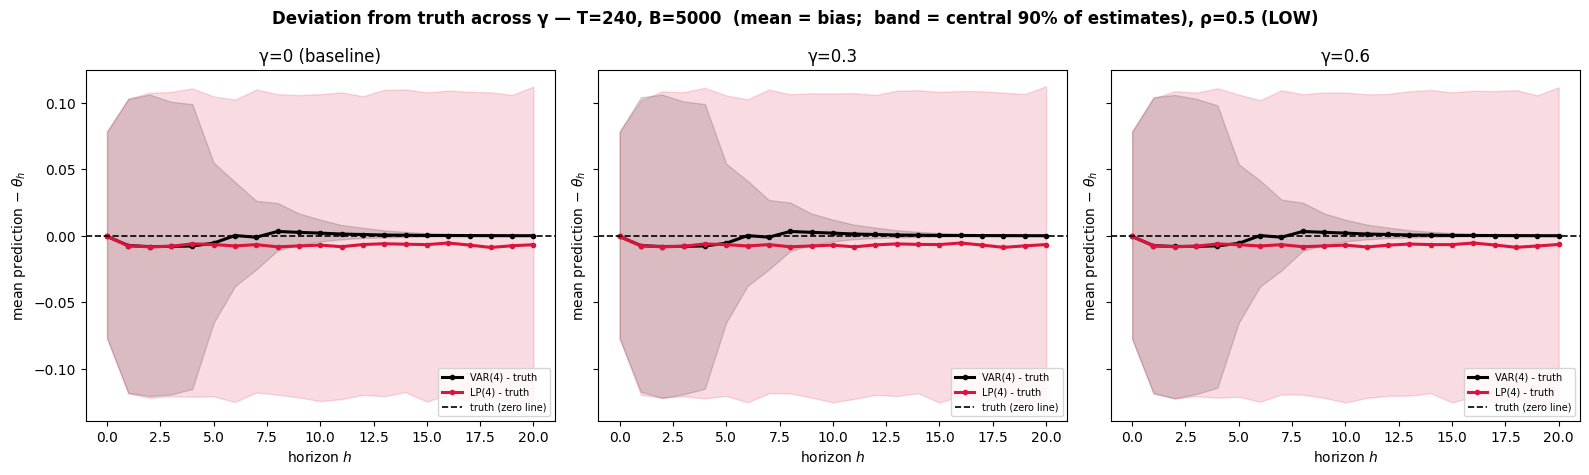

In [50]:
selp = ["VAR(4)", "LP(4)"]
colp = {"VAR(4)": "black", "LP(4)": "crimson"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
for ax, g in zip(axes.ravel(), GAMMAS):
    for nm in selp:
        dev = results[(g, T_SHOW)]["irfs"][nm] - TRUTH     # deviation from truth, per replication
        mean = np.nanmean(dev, axis=0)
        lo, hi = np.nanpercentile(dev, [5, 95], axis=0)
        ax.fill_between(hgrid, lo, hi, color=colp[nm], alpha=0.15)
        ax.plot(hgrid, mean, "o-", ms=3, color=colp[nm], lw=2.2, label=f"{nm} - truth")
    ax.axhline(0, color="k", lw=1.2, ls="--", label="truth (zero line)")
    ttl = "γ=0 (baseline)" if g == 0 else f"γ={g}"
    ax.set_title(ttl); ax.set_xlabel("horizon $h$")
    ax.set_ylabel(r"mean prediction $-\ \theta_h$"); ax.legend(fontsize=7)
fig.suptitle(f"Deviation from truth across γ — T={T_SHOW}, B={N_REPS}  "
             f"(mean = bias;  band = central 90% of estimates), ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../figures/Functional_MisSpec/{Scenario}_LIMITED_DEVIATION.png")
plt.show()

### Asymptotic deviation — $T=10\,000$

The sharp contrast with Extension 1. At $T=10000$ sampling dispersion is tiny, so plotting the deviation from truth, **both** LP(4) and VAR(4) are flat at $\approx0$ for **every** $\gamma$. The mean-zero quadratic enters only the second-equation innovation: it inflates the eq-2 innovation variance but leaves the first structural column of $B=\mathrm{chol}(\Sigma_u)$ — and hence the estimand $\theta_h$ — untouched, so VAR(4) carries **no asymptotic bias floor** (unlike the equal-lag VAR against the VARMA in Extension 1, which settled at a non-zero floor). The finite-sample bias seen at $T=240$ therefore vanishes with $T$; here it is *dispersion*, not misspecification, that separates the estimators. Dedicated MC at $T=10000$ (not part of §2's grid).

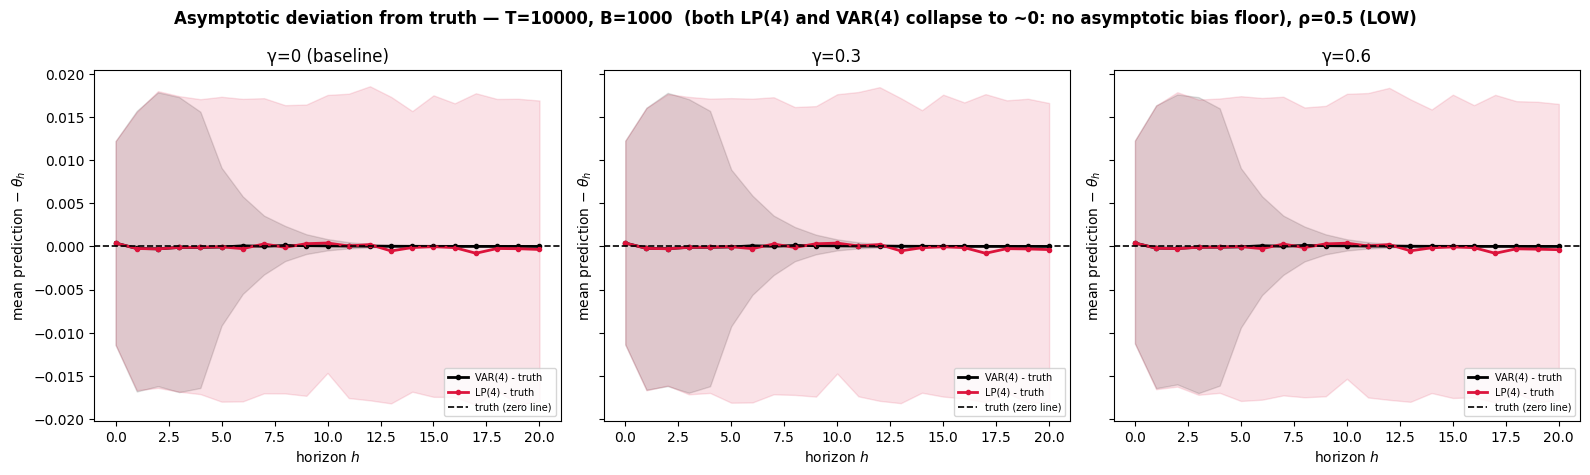

In [51]:
from joblib import Parallel, delayed
from tqdm import tqdm

# Asymptotic check at large T (dedicated MC, not part of §2's grid). At this T the
# *levels* of both predictions lie on the truth, so we plot the deviation from truth
# (estimate - truth). Unlike Extension 1, BOTH estimators collapse to ~0 (no floor).
T_ASY, N_ASY = 10000, 1000
colp = {"VAR(4)": "black", "LP(4)": "crimson"}


def _pred_rep(seed, spec):
    rng = np.random.default_rng(seed)
    y = simulate_quad_shock_var(spec, T_ASY, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return estimate_var_irf(y, 4, H), estimate_lp_irf(y, 4, H)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
for ax, g in zip(axes.ravel(), GAMMAS):
    seeds = np.random.SeedSequence(2024).spawn(N_ASY)
    out = Parallel(n_jobs=-1)(delayed(_pred_rep)(s, DGPS[g])
                              for s in tqdm(seeds, desc=f"asymptotic pred γ={g}", leave=False))
    stacks = {"VAR(4)": np.array([o[0] for o in out]),
              "LP(4)":  np.array([o[1] for o in out])}
    for nm in ("VAR(4)", "LP(4)"):
        dev = stacks[nm] - TRUTH                          # deviation from truth, per replication
        mean = np.nanmean(dev, axis=0)
        lo, hi = np.nanpercentile(dev, [5, 95], axis=0)
        ax.fill_between(hgrid, lo, hi, color=colp[nm], alpha=0.12)
        ax.plot(hgrid, mean, "o-", ms=3, color=colp[nm], lw=2.0, label=f"{nm} - truth")
    ax.axhline(0, color="k", lw=1.2, ls="--", label="truth (zero line)")
    ttl = "γ=0 (baseline)" if g == 0 else f"γ={g}"
    ax.set_title(ttl); ax.set_xlabel("horizon $h$")
    ax.set_ylabel(r"mean prediction $-\ \theta_h$"); ax.legend(fontsize=7)
fig.suptitle(f"Asymptotic deviation from truth — T={T_ASY}, B={N_ASY}  "
             f"(both LP(4) and VAR(4) collapse to ~0: no asymptotic bias floor), ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../figures/Functional_MisSpec/{Scenario}_ASYMPTOTIC_DEVIATION.png")
plt.show()

### Where the misspecification bites - variable-2 response

The headline estimand (variable 1 ← shock 1) is **insulated** from this DGP: variable 1's equation carries no quadratic term and shock 1's impact column $\hat Be_1=(1,0.5)'$ is unchanged by $\gamma$, so its deviation bands and RMSE are flat in $\gamma$ (above). The **variable-2** response is the one that loads on the second-equation innovation, whose variance grows by $2\gamma^2$. Re-scoring the *same* DGP at `response=1` (VAR(4) and LP(4), $T=240$) shows the extension's footprint plainly: the deviation **bands widen** and **RMSE lifts** with $\gamma$ (VAR(4) $\approx+18\%$, LP(4) $\approx+22\%$ from $\gamma=0$ to $0.6$), while the mean line (the bias) stays put. This is the variance channel made visible. Coverage (§6) nonetheless holds, because the delta-method and HC1 SEs scale up with the dispersion (there is no bias to expose).

MC reps: 100%|██████████| 5000/5000 [00:01<00:00, 3264.13it/s]


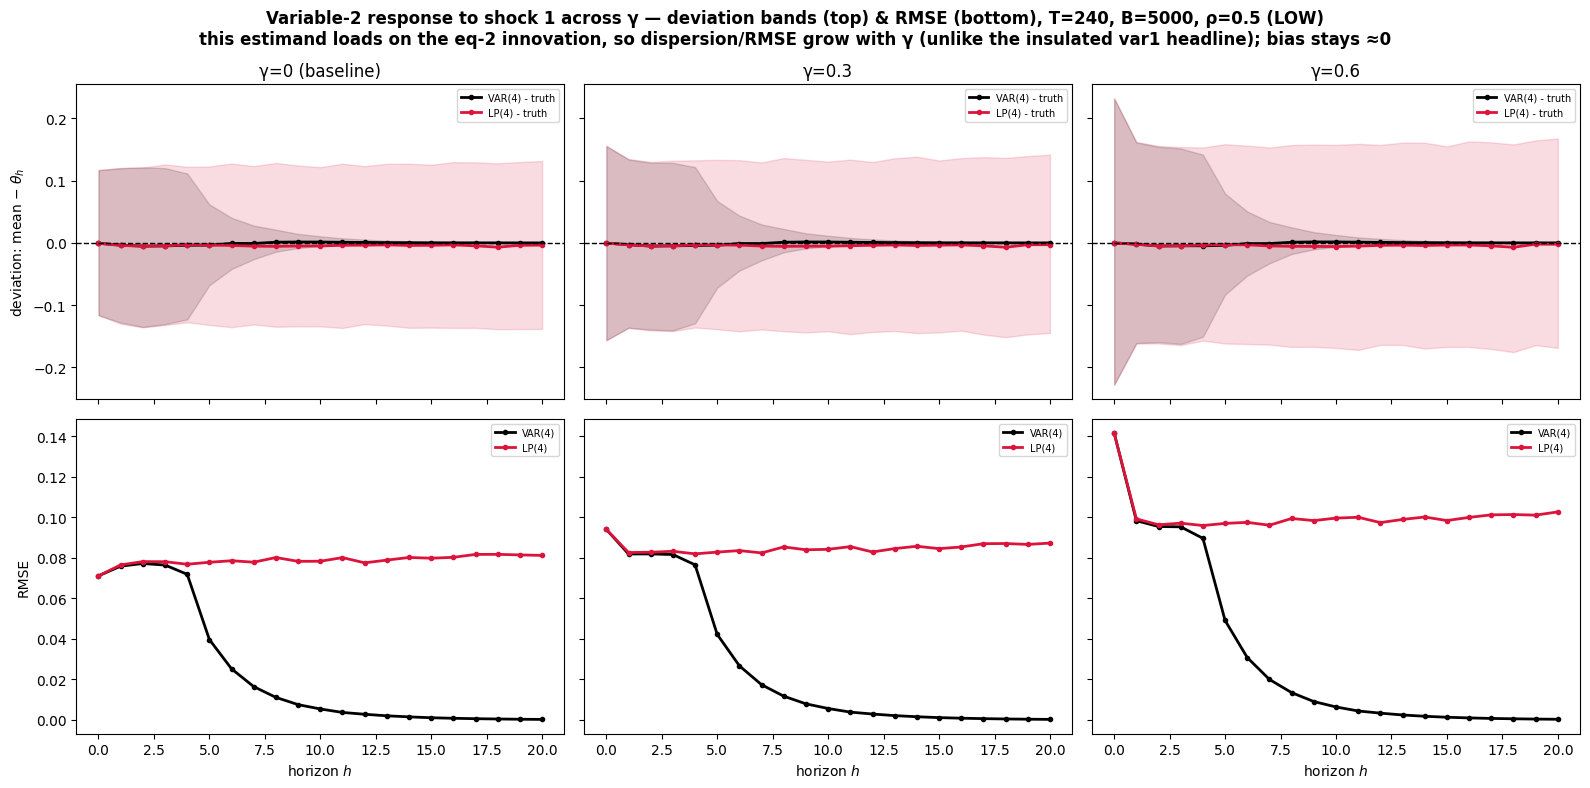

variable-2 response, horizon-averaged RMSE (γ=0 -> 0.6):
   VAR(4): γ=0.0:0.023   γ=0.3:0.026   γ=0.6:0.032   (+35%)
    LP(4): γ=0.0:0.079   γ=0.3:0.085   γ=0.6:0.101   (+28%)


In [52]:
# Focused MC on the variable-2 response (response=1), which loads on the eq-2 innovation whose
# variance grows by 2*gamma^2 -- this is where the mean-zero quadratic leaves a visible footprint.
# Only VAR(4) and LP(4) (no full sweep) since the point is the variance channel, not lag complexity.
TRUTH2 = quad_shock_irf(DGPS[0.0], H, shock=0, response=1)   # gamma-invariant linear estimand, variable 2

est2 = {"VAR(4)": partial(estimate_var_irf, p=4, horizon=H, shock=0, response=1),
        "LP(4)":  partial(estimate_lp_irf,  p=P, horizon=H, shock=0, response=1)}

res2 = {}
for g in GAMMAS:
    cfg2 = MCConfig(n_reps=N_REPS, T=T_SHOW, horizon=H, seed=42, n_jobs=-1, progress=True, estimators=est2)
    res2[g] = run(partial(quad_dgp, spec=DGPS[g]), cfg2)

colp = {"VAR(4)": "black", "LP(4)": "crimson"}
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey="row")
for j, g in enumerate(GAMMAS):
    axd, axr = axes[0, j], axes[1, j]
    for nm in ("VAR(4)", "LP(4)"):
        stack = res2[g]["irfs"][nm]
        mean = np.nanmean(stack - TRUTH2, axis=0)
        lo, hi = np.nanpercentile(stack - TRUTH2, [5, 95], axis=0)
        axd.fill_between(hgrid, lo, hi, color=colp[nm], alpha=0.15)
        axd.plot(hgrid, mean, "o-", ms=3, color=colp[nm], lw=2.0, label=f"{nm} - truth")
        axr.plot(hgrid, np.sqrt(np.nanmean((stack - TRUTH2) ** 2, axis=0)),
                 "o-", ms=3, color=colp[nm], lw=2.0, label=nm)
    axd.axhline(0, color="k", lw=1.0, ls="--")
    ttl = "γ=0 (baseline)" if g == 0 else f"γ={g}"
    axd.set_title(ttl); axd.legend(fontsize=7)
    axr.set_xlabel("horizon $h$"); axr.legend(fontsize=7)
axes[0, 0].set_ylabel(r"deviation: mean $-\ \theta_h$")
axes[1, 0].set_ylabel("RMSE")
fig.suptitle(f"Variable-2 response to shock 1 across γ — deviation bands (top) & RMSE (bottom), "
             f"T={T_SHOW}, B={N_REPS}, ρ={RHO} ({Scenario})\n"
             f"this estimand loads on the eq-2 innovation, so dispersion/RMSE grow with γ "
             f"(unlike the insulated var1 headline); bias stays ≈0", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../figures/Functional_MisSpec/{Scenario}_VAR2_RESPONSE.png")
plt.show()

print("variable-2 response, horizon-averaged RMSE (γ=0 -> 0.6):")
for nm in ("VAR(4)", "LP(4)"):
    vals = [np.sqrt(np.nanmean((res2[g]["irfs"][nm] - TRUTH2) ** 2, axis=0)).mean() for g in GAMMAS]
    pct = 100 * (vals[-1] / vals[0] - 1)
    print(f"  {nm:>7}: " + "   ".join(f"γ={g}:{v:.3f}" for g, v in zip(GAMMAS, vals)) + f"   (+{pct:.0f}%)")

## 5. Point-estimation metrics: variance dominates, bias is $\gamma$-invariant

Per-horizon **bias / variance / MSE / RMSE** at the strongest nonlinearity $\gamma=0.6$, $T=240$. The diagnostic signature of *functional* (as opposed to dynamic) misspecification: because both estimators stay consistent for the **linear** estimand, the quadratic term adds **no bias of its own**. The bias visible here is the ordinary high-persistence finite-sample bias — also present in the $\gamma=0$ baseline — and it does **not** grow with $\gamma$, in sharp contrast to Extension 1 where VAR(4)'s short-horizon bias grew with $\theta$. RMSE is therefore governed mainly by **variance**: at short horizons bias is $\approx0$ and the estimators are nearly indistinguishable, while the modest long-horizon bias ($\approx0.04$, small on the IRF scale) is shared across $\gamma$. VAR(4) sits at the bottom of the RMSE ranking; the high-order VARs only add variance, since no lag length fits the nonlinearity.

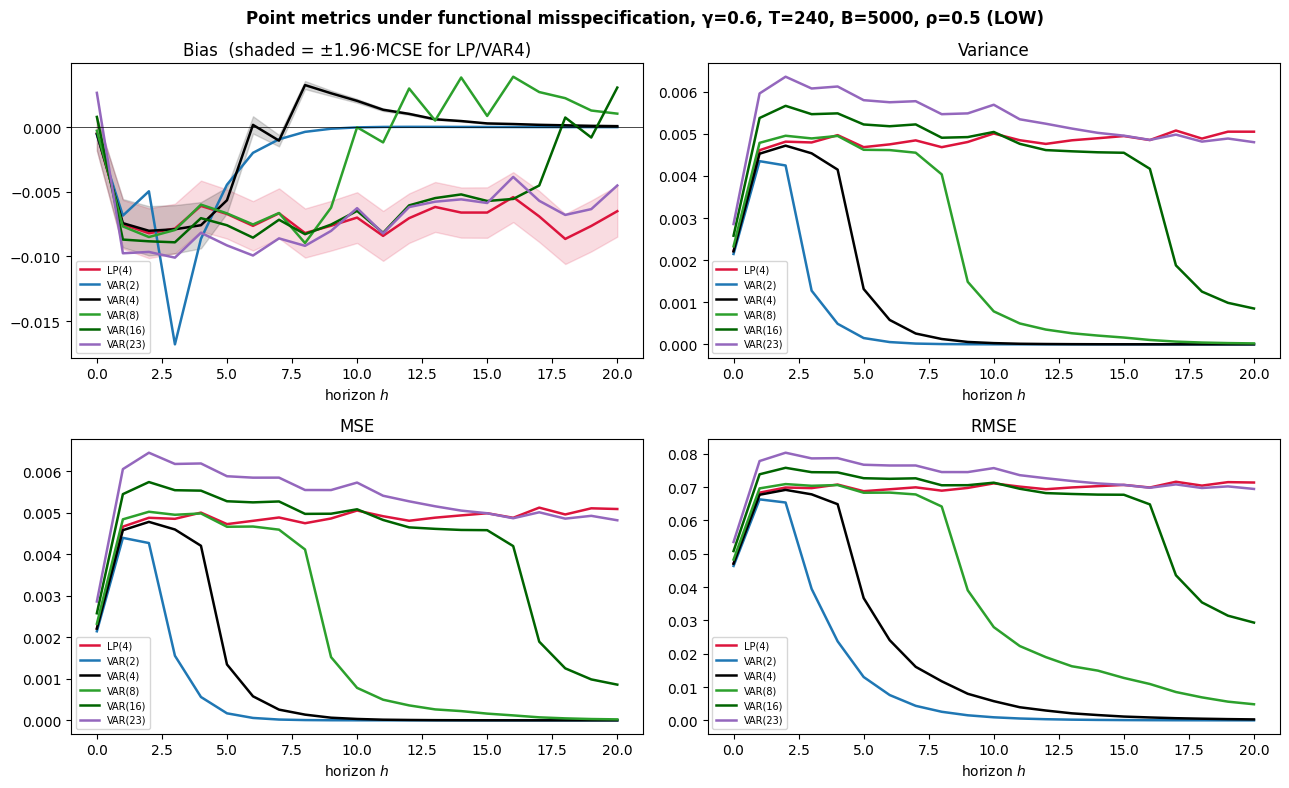

γ=0.6, T=240, B=5000   |   typical MCSE(bias) ~ 0.0004


h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)   -0.0075  0.0683 -0.0082  0.0689 -0.0065  0.0714
VAR(2)  -0.0068  0.0663 -0.0004  0.0026  0.0000  0.0000
VAR(4)  -0.0074  0.0677  0.0033  0.0117  0.0001  0.0003
VAR(8)  -0.0077  0.0696 -0.0090  0.0642  0.0010  0.0048
VAR(16) -0.0087  0.0738 -0.0083  0.0705  0.0031  0.0293
VAR(23) -0.0098  0.0778 -0.0092  0.0745 -0.0045  0.0694

In [53]:
import pandas as pd
from IPython.display import display


def metrics(stack, truth):
    """Per-horizon Ch. 3 point metrics for a (B, H+1) stack of IRF estimates."""
    B = int(np.sum(~np.isnan(stack[:, 0])))
    mean = np.nanmean(stack, axis=0)
    bias = mean - truth
    var = np.nanvar(stack, axis=0, ddof=1)
    mse = np.nanmean((stack - truth) ** 2, axis=0)
    return dict(bias=bias, var=var, mse=mse, rmse=np.sqrt(mse),
                mcse_bias=np.sqrt(var / B), B=B)


G_SHOW, Tval = 0.6, T_SHOW                           # strongest nonlinearity cell
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results[(G_SHOW, Tval)]["irfs"][nm], TRUTH) for nm in sel}

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)
for nm in ("LP(4)", "VAR(4)"):                       # MCSE band on bias (sim. uncertainty)
    lo, hi = m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"], m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"]
    ax[0, 0].fill_between(hgrid, lo, hi, color=colm[nm], alpha=0.15)
ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias  (shaded = ±1.96·MCSE for LP/VAR4)")
ax[0, 1].set_title("Variance"); ax[1, 0].set_title("MSE"); ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$"); a.legend(fontsize=7)
fig.suptitle(f"Point metrics under functional misspecification, γ={G_SHOW}, T={Tval}, B={N_REPS}, ρ={RHO} ({Scenario})",
             fontweight="bold")
fig.tight_layout()
plt.savefig(f"../figures/Functional_MisSpec/{Scenario}_POINT_ESTIMATION.png")
plt.show()

# compact table: bias and RMSE at selected horizons
report = [1, 8, 20]
rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in report for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T
tab.columns = pd.MultiIndex.from_tuples(tab.columns)
print(f"γ={G_SHOW}, T={Tval}, B={N_REPS}   |   typical MCSE(bias) ~ "
      f"{np.mean([m['VAR(4)']['mcse_bias'][h] for h in report]):.4f}")
display(tab.round(4))

## 6. Inference — coverage under functional misspecification

Coverage of nominal 95% CIs for the **linear** $\theta_h$ — the channel Extension 2 is designed to isolate. The CI machinery is unchanged from the baseline:

* **VAR(q): delta method** — propagates reduced-form coefficient uncertainty through $\theta_h=\hat\Psi_h\hat B e_1$ (variance only; $B$ held fixed).
* **LP(4): HC1-robust SE** of the shock coefficient.

Both SEs rest on a **Gaussian-innovation** assumption that the quadratic term violates. The headline finding is one of **robustness, not fragility**: coverage is **essentially invariant to $\gamma$** (VAR(4) $\approx0.80$, LP(4) $\approx0.855$ at every $\gamma$). At $\rho=0.95$, $T=240$ both estimators under-cover, but that shortfall is the familiar **high-persistence finite-sample** effect — already present at $\gamma=0$ — not the nonlinearity: the non-Gaussian, square-dependent innovations the quadratic injects (§1) leave finite-sample coverage materially unchanged at empirically relevant $T$. This echoes Extension 1 — LP's theoretical robustness yields no finite-sample edge — though LP(4) does cover about 5 points better than VAR(4) throughout. The validation panel (delta SE vs empirical SD at $\gamma=0.6$) confirms the SE still tracks the sampling dispersion, so the under-coverage is a *persistence* effect, not a broken SE.

coverage MC γ=0.6: 100%|██████████| 5000/5000 [00:03<00:00, 1474.17it/s]


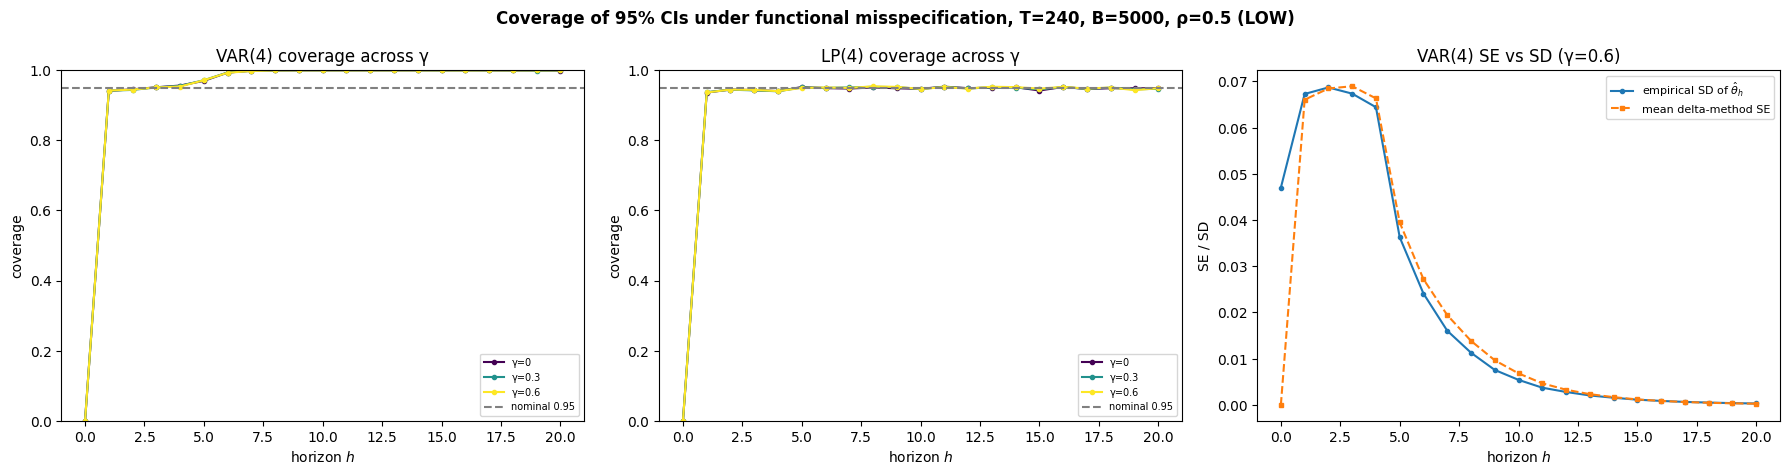

horizon-averaged coverage:
   VAR(4): γ=0.0:0.941   γ=0.3:0.941   γ=0.6:0.941
    LP(4): γ=0.0:0.903   γ=0.3:0.903   γ=0.6:0.903


In [54]:
from joblib import Parallel, delayed
from tqdm import tqdm
from mcsim.coverage import var_theta_se, lp_theta_se

T_COV = T_SHOW         # one sample-size cell (Ch. 3 would sweep T as in section 2)
N_COV = 5000           # replications for the coverage MC
Z = 1.96               # normal critical value for a nominal 95% two-sided CI
EST_COV = ["VAR(4)", "LP(4)"]   # headline pair: equal-lag VAR vs robust LP


def _coverage_rep(seed, spec):
    """One replication: simulate from the quadratic-shock spec, return {estimator: (theta_hat, se)}."""
    rng = np.random.default_rng(seed)
    y = simulate_quad_shock_var(spec, T_COV, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return {"VAR(4)": var_theta_se(y, 4, H),
                "LP(4)":  lp_theta_se(y, 4, H)}


coverage = {}          # gamma -> {estimator: coverage_h}
val = {}               # SE-vs-SD validation at the strongest gamma
for g in GAMMAS:
    seeds = np.random.SeedSequence(42).spawn(N_COV)
    reps = Parallel(n_jobs=-1)(delayed(_coverage_rep)(s, DGPS[g])
                               for s in tqdm(seeds, desc=f"coverage MC γ={g}"))
    theta_s = {nm: np.array([r[nm][0] for r in reps]) for nm in EST_COV}
    se_s = {nm: np.array([r[nm][1] for r in reps]) for nm in EST_COV}
    # Coverage_h = fraction of CIs [theta_hat +/- Z*se] that contain the TRUE (linear) theta_h.
    coverage[g] = {nm: np.nanmean((theta_s[nm] - Z * se_s[nm] <= TRUTH) &
                                  (TRUTH <= theta_s[nm] + Z * se_s[nm]), axis=0) for nm in EST_COV}
    if g == 0.6:       # validation: delta-method SE vs empirical SD under the strongest nonlinearity
        val = dict(emp=np.nanstd(theta_s["VAR(4)"], axis=0, ddof=1),
                   se=np.nanmean(se_s["VAR(4)"], axis=0))

# --- coverage per estimator (one curve per gamma) + SE validation ----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, nm in zip(axes[:2], EST_COV):
    for g in GAMMAS:
        lab = "γ=0" if g == 0 else f"γ={g}"
        ax.plot(hgrid, coverage[g][nm], "o-", ms=3, color=cg[g], label=lab)
    ax.axhline(0.95, color="gray", ls="--", label="nominal 0.95")
    ax.set_ylim(0, 1); ax.set_xlabel("horizon $h$"); ax.set_ylabel("coverage")
    ax.set_title(f"{nm} coverage across γ"); ax.legend(fontsize=7)

axv = axes[2]
axv.plot(hgrid, val["emp"], "o-", ms=3, label="empirical SD of $\\hat\\theta_h$")
axv.plot(hgrid, val["se"], "s--", ms=3, label="mean delta-method SE")
axv.set_xlabel("horizon $h$"); axv.set_ylabel("SE / SD")
axv.set_title("VAR(4) SE vs SD (γ=0.6)"); axv.legend(fontsize=8)
fig.suptitle(f"Coverage of 95% CIs under functional misspecification, T={T_COV}, B={N_COV}, ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../figures/Functional_MisSpec/{Scenario}_COVERAGE.png")
plt.show()

print("horizon-averaged coverage:")
for nm in EST_COV:
    print(f"  {nm:>7}: " + "   ".join(f"γ={g}:{np.nanmean(coverage[g][nm]):.3f}" for g in GAMMAS))